# OpenMP scaling analysis

Nur OpenMP / shared memory.

Parameter:
-    "wp":"real64"
-    "ratio_x":1
-    "ratio_y":1
-    "frames":100
-    "delta_frames":1
-    "periodicity":true
-    "preset":"random"


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('times.csv')

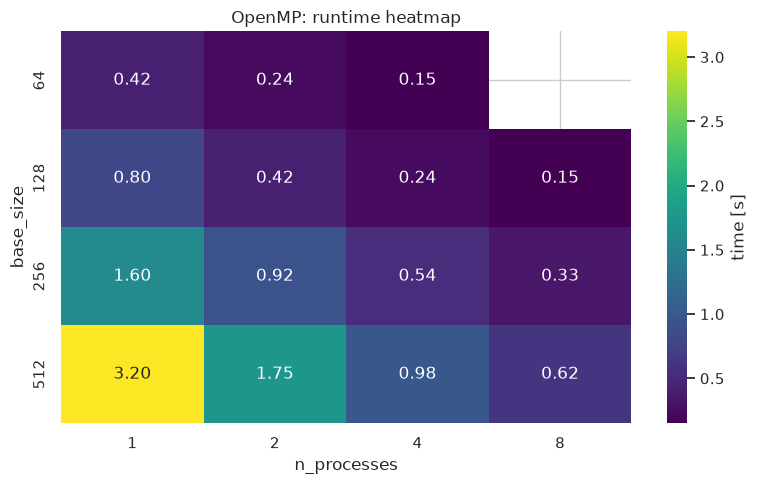

In [14]:
heat = df.pivot_table(index='base_size', columns='n_processes', values='time_s')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'time [s]'}, ax=ax)
ax.set_title('OpenMP: runtime heatmap')
ax.set_xlabel('n_processes')
ax.set_ylabel('base_size')
plt.tight_layout()
plt.show()

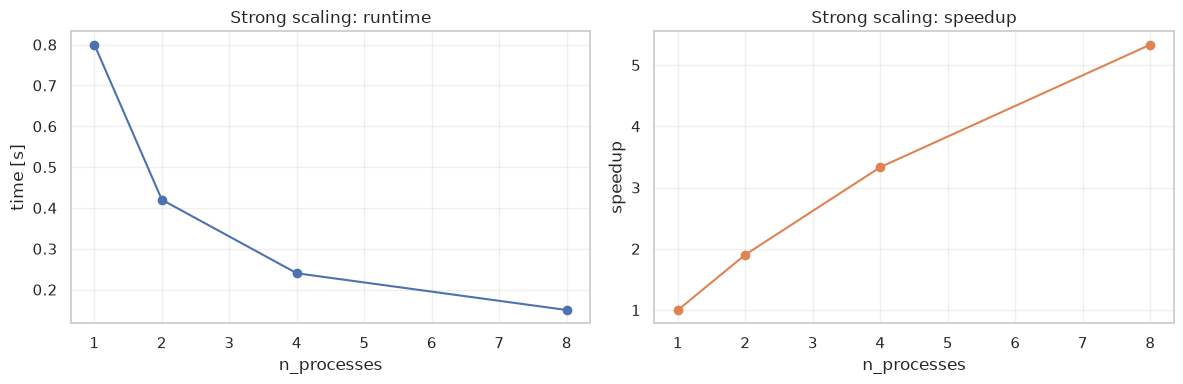

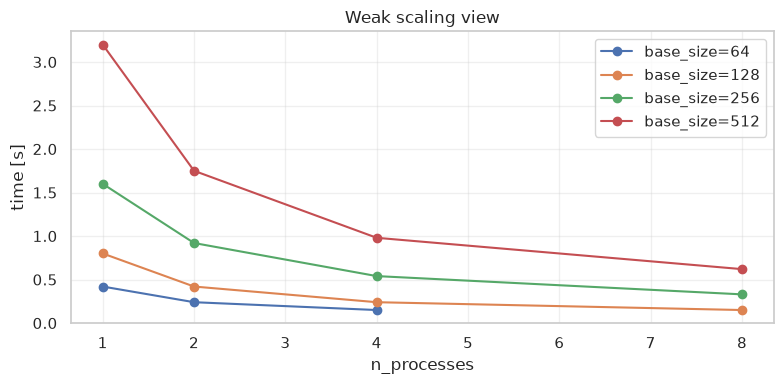

In [9]:
strong = df[df['base_size'] == 128].sort_values('n_processes').copy()
strong['speedup'] = strong['time_s'].iloc[0] / strong['time_s']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(strong['n_processes'], strong['time_s'], marker='o')
axes[0].set_title('Strong scaling: runtime')
axes[0].set_xlabel('n_processes')
axes[0].set_ylabel('time [s]')

axes[1].plot(strong['n_processes'], strong['speedup'], marker='o', color='C1')
axes[1].set_title('Strong scaling: speedup')
axes[1].set_xlabel('n_processes')
axes[1].set_ylabel('speedup')

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

weak = df.copy()
fig, ax = plt.subplots(figsize=(8, 4))
for size, group in weak.groupby('base_size'):
    ax.plot(group['n_processes'], group['time_s'], marker='o', label=f'base_size={size}')
ax.set_title('Weak scaling view')
ax.set_xlabel('n_processes')
ax.set_ylabel('time [s]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()